In [1]:
from google.colab import drive; drive.mount('/content/drive')
import os

# ── SET YOUR PATHS ─────────────────────────────────────────────
BASE     = '/content/drive/MyDrive/Mental-Health'
DAIC     = os.path.join(BASE, 'DAIC')
EXT_DAIC = os.path.join(BASE, 'Extended-DAIC', 'data')
KAGGLE   = os.path.join(BASE, 'kaggle', 'depression_kaggle.csv')
OUT      = os.path.join(BASE, 'outputs', 'text')
os.makedirs(OUT, exist_ok=True)
# ───────────────────────────────────────────────────────────────

print(f'DAIC          : {os.path.isdir(DAIC)}')
print(f'Extended-DAIC : {os.path.isdir(EXT_DAIC)}')
print(f'Kaggle        : {os.path.exists(KAGGLE)}')

Mounted at /content/drive
DAIC          : True
Extended-DAIC : True
Kaggle        : True


In [2]:
!pip install -q transformers==4.40.0 scikit-learn lightgbm imbalanced-learn torch
import torch
print('GPU:', torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 50.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
GPU: True Tesla T4


In [3]:
import os, re, json, random, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm
import joblib

BERT_MODEL  = 'mental/mental-bert-base-uncased'
MAX_LEN     = 256
BATCH_SIZE  = 16 
EPOCHS_S1   = 25
EPOCHS_S2   = 10
LR_HEAD     = 5e-4
LR_BERT     = 1e-5
PATIENCE    = 7
BINARY_THR  = 10
SEED        = 42
KAGGLE_N    = 400

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASS_NAMES = ['Not depressed', 'Depressed']

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('Device:', DEVICE)

Device: cuda


## Step 1 — Text cleaning

In [4]:
BRACKET = re.compile(r'\[.*?\]|\(.*?\)')
FILLER  = re.compile(r'\b(um|uh|hmm|mm|mhm|uh-huh|yeah|okay|ok|like|you know)\b', re.I)
SPACE   = re.compile(r'\s+')

def clean(text):
    text = BRACKET.sub(' ', text)
    text = FILLER.sub(' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s\'\-\.\!\?]', ' ', text)
    return SPACE.sub(' ', text).strip().lower()

print('Cleaning ready')

Cleaning ready


## Step 2 — Label loading

In [5]:
def load_labels(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    phq = next((c for c in df.columns if 'phq' in c and ('score' in c or '8' in c)), None)
    if phq is None: phq = next((c for c in df.columns if 'phq' in c), None)
    if phq is None: phq = next((c for c in df.columns if 'severity' in c or 'score' in c), None)
    pid = next((c for c in df.columns if 'participant' in c or c=='id' or 'subject' in c), None)
    if phq is None or pid is None:
        print(f'  [WARN] cols: {list(df.columns)}')
        return pd.DataFrame(columns=['participant_id','phq_score','label'])
    print(f'  PHQ={phq} | ID={pid}')
    df['label'] = (df[phq].astype(float) >= BINARY_THR).astype(int)
    df = df.rename(columns={pid:'participant_id', phq:'phq_score'})
    result = df[['participant_id','phq_score','label']].dropna()
    result['participant_id'] = result['participant_id'].astype(int)
    print(f'  {len(result)} labels | dep={result.label.sum()} | non-dep={(result.label==0).sum()}')
    return result

def find_label_file(data_dir):
    parent = os.path.dirname(data_dir)
    for p in [os.path.join(parent,'labels.csv'), os.path.join(data_dir,'labels.csv'),
              os.path.join(parent,'label.csv'),
              os.path.join(parent,'train_split_Depression_AVEC2017.csv'),
              os.path.join(parent,'dev_split_Depression_AVEC2017.csv')]:
        if os.path.exists(p): print(f'  Found: {p}'); return p
    return None

print('=== DAIC-WOZ labels ===')
daic_lbl_path = os.path.join(DAIC,'labels.csv')
if not os.path.exists(daic_lbl_path): daic_lbl_path = find_label_file(DAIC)
daic_labels = load_labels(daic_lbl_path)

print('\n=== Extended-DAIC labels ===')
ext_lbl_path = find_label_file(EXT_DAIC)
ext_labels   = load_labels(ext_lbl_path) if ext_lbl_path else \
               pd.DataFrame(columns=['participant_id','phq_score','label'])

all_labels = pd.concat([ext_labels, daic_labels], ignore_index=True)\
               .drop_duplicates('participant_id', keep='first')
print(f'\nTotal unique: {len(all_labels)} | dep={all_labels.label.sum()}')

=== DAIC-WOZ labels ===
  PHQ=phq8_score | ID=participant_id
  142 labels | dep=43 | non-dep=99

=== Extended-DAIC labels ===

Total unique: 142 | dep=43


## Step 3 — Load transcripts from both datasets

In [6]:
def extract_text(path, pid):
    try:
        df = pd.read_csv(path)
        df.columns = [c.strip().lower() for c in df.columns]
    except: return None
    sp = next((c for c in df.columns if any(k in c for k in ['speaker','who','role'])), None)
    tx = next((c for c in df.columns if any(k in c for k in ['value','text','utt','content','word'])), None)
    if sp and tx:
        mask  = ~df[sp].astype(str).str.upper().str.strip().isin({'ELLIE','INTERVIEWER','E','INT'})
        sents = [s for s in df[mask][tx].dropna().astype(str).tolist() if len(s.split()) >= 5]
    elif tx:
        sents = [s for s in df[tx].dropna().astype(str).tolist() if len(s.split()) >= 5]
    else:
        sents = df.iloc[:,-1].dropna().astype(str).tolist()
    text = clean(' '.join(sents))
    return text if len(text.split()) >= 10 else None

def find_transcript(pdir, pid):
    for p in [f'{pid}_TRANSCRIPT.csv', f'{pid}_Transcript.csv',
              f'{pid}_transcript.csv', 'Transcript.csv']:
        full = os.path.join(pdir, p)
        if os.path.exists(full): return full
    return None

def load_from_dir(data_dir, lut, tag, seen=None):
    if seen is None: seen = set()
    dirs = sorted([d for d in os.listdir(data_dir)
                   if os.path.isdir(os.path.join(data_dir,d)) and d.endswith('_P')])
    records, skip_lbl, skip_dup, skip_txt = [], 0, 0, 0
    for folder in tqdm(dirs, desc=tag):
        try: pid = int(folder.split('_')[0])
        except: continue
        if pid not in lut:       skip_lbl += 1; continue
        if pid in seen:          skip_dup += 1; continue
        tp = find_transcript(os.path.join(data_dir,folder), pid)
        if tp is None:           skip_txt += 1; continue
        text = extract_text(tp, pid)
        if text is None:         skip_txt += 1; continue
        row = lut[pid]
        records.append({'participant_id':pid,'text':text,
                        'label':int(row['label']),'phq_score':float(row['phq_score']),'source':tag})
        seen.add(pid)
    print(f'[{tag}] loaded={len(records)} | no_lbl={skip_lbl} | dup={skip_dup} | no_txt={skip_txt}')
    return pd.DataFrame(records), seen

lut = all_labels.set_index('participant_id').to_dict('index')
daic_df,  seen = load_from_dir(DAIC,     lut, 'DAIC-WOZ')
ext_df,   seen = load_from_dir(EXT_DAIC, lut, 'Extended', seen) if os.path.isdir(EXT_DAIC) \
                 else (pd.DataFrame(columns=daic_df.columns), seen)

combined_df = pd.concat([daic_df, ext_df], ignore_index=True)
print(f'\nCombined: {len(combined_df)} | dep={combined_df.label.sum()} | non-dep={(combined_df.label==0).sum()}')

DAIC-WOZ:   0%|          | 0/189 [00:00<?, ?it/s]

[DAIC-WOZ] loaded=142 | no_lbl=47 | dup=0 | no_txt=0


Extended:   0%|          | 0/275 [00:00<?, ?it/s]

[Extended] loaded=0 | no_lbl=133 | dup=142 | no_txt=0

Combined: 142 | dep=43 | non-dep=99


## Step 4 — Kaggle depressed samples

In [7]:
def load_kaggle(path, max_n=KAGGLE_N):
    if not os.path.exists(path): print('Kaggle not found'); return None
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    tx = next((c for c in df.columns if 'text' in c or 'post' in c or 'sentence' in c), None)
    lb = next((c for c in df.columns if 'label' in c or 'class' in c), None)
    if tx is None: print('No text col'); return None
    df['text']  = df[tx].astype(str).apply(clean)
    df['label'] = df[lb].astype(int).clip(0,1) if lb else 1
    df = df[df['label']==1]
    df = df[df['text'].str.split().str.len() >= 15]
    df = df.sample(min(len(df), max_n), random_state=SEED)
    df[['participant_id','phq_score','source']] = -1, float('nan'), 'Kaggle'
    print(f'Kaggle depressed samples: {len(df)}')
    return df[['participant_id','text','label','phq_score','source']]

kaggle_df = load_kaggle(KAGGLE)

Kaggle depressed samples: 400


## Step 5 — Stratified split

In [8]:
tv, test_df = train_test_split(combined_df, test_size=0.15,
                               stratify=combined_df['label'], random_state=SEED)
train_clin, val_df = train_test_split(tv, test_size=0.15/0.85,
                                      stratify=tv['label'], random_state=SEED)

train_df = pd.concat([train_clin, kaggle_df], ignore_index=True)\
             .sample(frac=1, random_state=SEED).reset_index(drop=True) \
             if kaggle_df is not None else train_clin.reset_index(drop=True)

n0 = (train_clin['label']==0).sum()
n1 = (train_clin['label']==1).sum()
POS_W = torch.tensor([n0/max(n1,1)], dtype=torch.float32).to(DEVICE)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Clinical train dist: {dict(train_clin.label.value_counts().sort_index())}')
print(f'pos_weight={POS_W.item():.3f}')

Train: 498 | Val: 22 | Test: 22
Clinical train dist: {0: np.int64(69), 1: np.int64(29)}
pos_weight=2.379


## Step 6 — MentalBERT model (domain-specific — key upgrade)

In [9]:
print(f'Loading tokenizer: {BERT_MODEL}')
try:
    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
    print('MentalBERT tokenizer loaded ✅')
except Exception as e:
    print(f'MentalBERT not available ({e})')
    print('Falling back to roberta-base')
    BERT_MODEL = 'roberta-base'
    tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL)

class TranscriptDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=MAX_LEN, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {'input_ids':      self.enc['input_ids'][i],
                'attention_mask': self.enc['attention_mask'][i],
                'labels':         self.labels[i]}

train_ds = TranscriptDataset(train_df['text'], train_df['label'])
val_ds   = TranscriptDataset(val_df['text'],   val_df['label'])
test_ds  = TranscriptDataset(test_df['text'],  test_df['label'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Loading tokenizer: mental/mental-bert-base-uncased
MentalBERT not available (You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
401 Client Error. (Request ID: Root=1-69cc0f23-5b2a3e90516a1c6536e6f2bd;0290eab3-27a8-4770-942a-0e3b257d40e5)

Cannot access gated repo for url https://huggingface.co/mental/mental-bert-base-uncased/resolve/main/config.json.
Access to model mental/mental-bert-base-uncased is restricted. You must have access to it and be authenticated to access it. Please log in.)
Falling back to roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 32 | Val: 2 | Test: 2


## Step 7 — Model architecture

In [10]:
class MentalBERTClassifier(nn.Module):
    """MentalBERT with frozen body in Stage 1, gradual unfreeze in Stage 2."""
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(BERT_MODEL)
        H = self.bert.config.hidden_size  # 768
        for p in self.bert.parameters(): p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(H*2, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def unfreeze_top(self, n=3):
        # MentalBERT/BERT uses .encoder.layer
        try: layers = self.bert.encoder.layer
        except: layers = self.bert.transformer.layer
        for layer in layers[-n:]:
            for p in layer.parameters(): p.requires_grad = True
        try:
            for p in self.bert.pooler.parameters(): p.requires_grad = True
        except: pass
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Unfroze top {n} layers | trainable={trainable:,}')

    def _pool(self, out, mask):
        h    = out.last_hidden_state
        cls  = h[:, 0, :]
        mx   = mask.unsqueeze(-1).expand(h.size()).float()
        mean = torch.sum(h*mx, 1) / torch.clamp(mx.sum(1), min=1e-9)
        return torch.cat([cls, mean], dim=-1)  # (B, 1536)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.head(self._pool(out, attention_mask))

    def get_embedding(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self._pool(out, attention_mask)

model    = MentalBERTClassifier().to(DEVICE)
head_p   = sum(p.numel() for p in model.head.parameters())
total_p  = sum(p.numel() for p in model.parameters())
bce_loss = nn.BCEWithLogitsLoss(pos_weight=POS_W)

def criterion(logits, labels):
    return bce_loss(logits[:,1].float(), labels.float())

print(f'Model: {BERT_MODEL}')
print(f'Total params: {total_p:,} | Head only (trainable): {head_p:,}')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: roberta-base
Total params: 125,499,522 | Head only (trainable): 853,890


## Step 8 — Stage 1: Train head only

In [11]:
save_path = os.path.join(OUT, 'mentalbert_model.pt')
opt_s1    = torch.optim.AdamW(model.head.parameters(), lr=LR_HEAD, weight_decay=0.01)
total_s1  = len(train_loader) * EPOCHS_S1
sch_s1    = get_cosine_schedule_with_warmup(opt_s1, total_s1//10, total_s1)
best_auc  = -1.0; pat = 0
hist      = {'tl':[], 'vl':[], 'vauc':[], 'vf1':[]}

print(f'STAGE 1 — head only, {EPOCHS_S1} epochs')
for ep in range(EPOCHS_S1):
    model.train(); tl = 0.0
    for b in train_loader:
        ids=b['input_ids'].to(DEVICE); msk=b['attention_mask'].to(DEVICE); lbl=b['labels'].to(DEVICE)
        opt_s1.zero_grad()
        loss = criterion(model(ids,msk), lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.head.parameters(), 1.0)
        opt_s1.step(); sch_s1.step(); tl += loss.item()
    tl /= len(train_loader)

    model.eval(); vl=0.0; vp,vt=[],[]
    with torch.no_grad():
        for b in val_loader:
            ids=b['input_ids'].to(DEVICE); msk=b['attention_mask'].to(DEVICE); lbl=b['labels'].to(DEVICE)
            logits=model(ids,msk)
            vl += criterion(logits,lbl).item()
            vp.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())
            vt.extend(lbl.cpu().numpy())
    vl/=len(val_loader)
    vpa, vta = np.array(vp), np.array(vt)
    try: vauc = roc_auc_score(vta, vpa)
    except: vauc = 0.5
    vf1 = f1_score(vta,(vpa>=0.5).astype(int),average='macro',zero_division=0)

    hist['tl'].append(tl); hist['vl'].append(vl)
    hist['vauc'].append(vauc); hist['vf1'].append(vf1)

    flag = ''
    if vauc > best_auc:
        best_auc=vauc; pat=0
        torch.save(model.state_dict(), save_path)
        np.save(os.path.join(OUT,'val_probs.npy'), vpa)
        np.save(os.path.join(OUT,'val_labels.npy'), vta)
        flag='  ✅'
    else:
        pat+=1
        if pat>=PATIENCE: print(f'  Early stop ep{ep+1}'); break
        flag=f'  ⏳{pat}/{PATIENCE}'
    print(f'S1 Ep{ep+1:02d} | loss={tl:.4f} | AUC={vauc:.4f} | macroF1={vf1:.4f}{flag}')

print(f'Stage 1 done | best AUC={best_auc:.4f}')

STAGE 1 — head only, 25 epochs
S1 Ep01 | loss=0.9440 | AUC=0.3048 | macroF1=0.2414  ✅
S1 Ep02 | loss=0.2640 | AUC=0.3048 | macroF1=0.4271  ⏳1/7
S1 Ep03 | loss=0.2075 | AUC=0.3619 | macroF1=0.4054  ✅
S1 Ep04 | loss=0.2043 | AUC=0.3524 | macroF1=0.3889  ⏳1/7
S1 Ep05 | loss=0.1909 | AUC=0.3524 | macroF1=0.3529  ⏳2/7
S1 Ep06 | loss=0.1997 | AUC=0.3619 | macroF1=0.3529  ⏳3/7
S1 Ep07 | loss=0.1854 | AUC=0.3429 | macroF1=0.3714  ⏳4/7
S1 Ep08 | loss=0.1817 | AUC=0.3238 | macroF1=0.3529  ⏳5/7
S1 Ep09 | loss=0.1794 | AUC=0.3714 | macroF1=0.3714  ✅
S1 Ep10 | loss=0.1785 | AUC=0.4952 | macroF1=0.3714  ✅
S1 Ep11 | loss=0.1620 | AUC=0.3619 | macroF1=0.4271  ⏳1/7
S1 Ep12 | loss=0.1791 | AUC=0.3429 | macroF1=0.4271  ⏳2/7
S1 Ep13 | loss=0.1707 | AUC=0.3524 | macroF1=0.4271  ⏳3/7
S1 Ep14 | loss=0.1772 | AUC=0.3905 | macroF1=0.3529  ⏳4/7
S1 Ep15 | loss=0.1594 | AUC=0.4667 | macroF1=0.3529  ⏳5/7
S1 Ep16 | loss=0.1755 | AUC=0.3905 | macroF1=0.3529  ⏳6/7
  Early stop ep17
Stage 1 done | best AUC=0.4952


## Step 9 — Stage 2: Fine-tune top 3 layers

In [12]:
model.load_state_dict(torch.load(save_path, map_location=DEVICE))

if best_auc > 0.58:
    print(f'AUC={best_auc:.3f} → Stage 2')
    model.unfreeze_top(n=3)
    opt_s2 = torch.optim.AdamW([
        {'params': [p for p in model.bert.parameters() if p.requires_grad], 'lr': LR_BERT},
        {'params': model.head.parameters(), 'lr': LR_HEAD*0.2}
    ], weight_decay=0.01)
    total_s2 = len(train_loader)*EPOCHS_S2
    sch_s2   = get_cosine_schedule_with_warmup(opt_s2, total_s2//10, total_s2)
    best2=best_auc; pat2=0

    for ep in range(EPOCHS_S2):
        model.train(); tl=0.0
        for b in train_loader:
            ids=b['input_ids'].to(DEVICE); msk=b['attention_mask'].to(DEVICE); lbl=b['labels'].to(DEVICE)
            opt_s2.zero_grad()
            loss=criterion(model(ids,msk),lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt_s2.step(); sch_s2.step(); tl+=loss.item()
        tl/=len(train_loader)
        model.eval(); vp2,vt2=[],[]
        with torch.no_grad():
            for b in val_loader:
                ids=b['input_ids'].to(DEVICE); msk=b['attention_mask'].to(DEVICE)
                vp2.extend(torch.softmax(model(ids,msk),-1)[:,1].cpu().numpy())
                vt2.extend(b['labels'].numpy())
        vp2,vt2=np.array(vp2),np.array(vt2)
        try: auc2=roc_auc_score(vt2,vp2)
        except: auc2=0.5
        flag=''
        if auc2>best2:
            best2=auc2; pat2=0
            torch.save(model.state_dict(),save_path)
            np.save(os.path.join(OUT,'val_probs.npy'), vp2)
            np.save(os.path.join(OUT,'val_labels.npy'), vt2)
            flag='  ✅'
        else:
            pat2+=1
            if pat2>=3: print('  S2 early stop'); break
        print(f'  S2 Ep{ep+1} | loss={tl:.4f} | AUC={auc2:.4f}{flag}')
    best_auc=max(best_auc,best2)
    print(f'Stage 2 done | best AUC={best_auc:.4f}')
else:
    print(f'AUC={best_auc:.3f} — skipping Stage 2')

AUC=0.495 — skipping Stage 2


## Step 10 — Optimal threshold search for BERT

BERT optimal threshold: 0.40  (macro F1=0.4271)


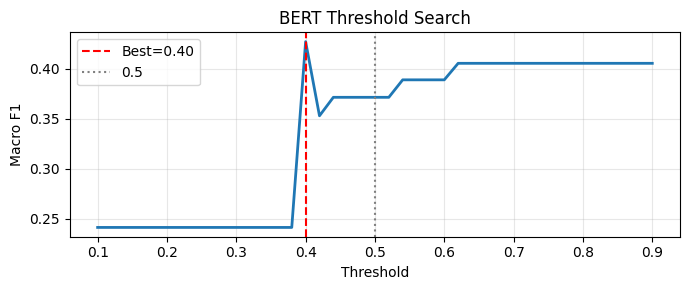

In [13]:
vpa_saved = np.load(os.path.join(OUT,'val_probs.npy'))
vta_saved = np.load(os.path.join(OUT,'val_labels.npy'))

thrs = np.arange(0.1, 0.91, 0.02)
mf1s = [f1_score(vta_saved,(vpa_saved>=t).astype(int),average='macro',zero_division=0) for t in thrs]
BERT_THR = float(thrs[np.argmax(mf1s)])
print(f'BERT optimal threshold: {BERT_THR:.2f}  (macro F1={max(mf1s):.4f})')

plt.figure(figsize=(7,3))
plt.plot(thrs,mf1s,lw=2)
plt.axvline(BERT_THR,color='red',linestyle='--',label=f'Best={BERT_THR:.2f}')
plt.axvline(0.5,color='gray',linestyle=':',label='0.5')
plt.xlabel('Threshold'); plt.ylabel('Macro F1'); plt.title('BERT Threshold Search')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT,'threshold_bert.png'),dpi=150); plt.show()

## Step 11 — TF-IDF features + SMOTE

In [14]:
KEYWORDS = [
    'sad','depress','hopeless','worthless','tired','empty','alone','anxious',
    'cry','sleep','energy','concentrate','guilty','fail','die','hurt','pain',
    'nothing','nobody','never','always','worst','lonely','isolat','numb',
    'miserable','useless','burden','numb','withdrawn','exhausted','trapped'
]

def keyword_features(texts):
    feats = []
    for t in texts:
        w = t.lower().split(); n = max(len(w),1)
        hits = sum(1 for x in w if any(k in x for k in KEYWORDS))
        neg  = sum(1 for x in w if x in ['not','no','never','cant','cannot','dont','wont'])
        q    = sum(1 for x in w if '?' in x)
        feats.append([len(w), len(set(w))/n, hits/n, neg/n, q/n,
                      len([x for x in w if x in ['i','me','my','myself','mine']])/n])  # self-ref rate
    return np.array(feats, dtype=np.float32)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,3),
                        sublinear_tf=True, min_df=1, analyzer='word')

def build_X(df, fit=False):
    texts = df['text'].tolist()
    Xtf = tfidf.fit_transform(texts).toarray() if fit else tfidf.transform(texts).toarray()
    return np.hstack([Xtf, keyword_features(texts)])

Xtr_raw = build_X(train_df, fit=True)
Xva     = build_X(val_df)
Xte     = build_X(test_df)
ytr_raw = train_df['label'].values
yva     = val_df['label'].values
yte     = test_df['label'].values

# SMOTE on training data to balance classes
k_sm = max(1, min(4, np.bincount(ytr_raw).min()-1))
if k_sm >= 1 and len(np.unique(ytr_raw)) > 1:
    sm = SMOTE(k_neighbors=k_sm, random_state=SEED)
    Xtr, ytr = sm.fit_resample(Xtr_raw, ytr_raw)
    print(f'SMOTE: {len(ytr_raw)} → {len(ytr)} samples | dist={np.bincount(ytr)}')
else:
    Xtr, ytr = Xtr_raw, ytr_raw
    print(f'SMOTE skipped | train size={len(ytr)}')

SMOTE: 498 → 858 samples | dist=[429 429]


## Step 12 — Train LightGBM, LinearSVC, LogisticRegression

In [15]:
cw_arr  = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr)
sw_arr  = np.array([cw_arr[l] for l in ytr])
n0,n1   = np.bincount(ytr)

# ── LightGBM ──────────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators=800, max_depth=4, learning_rate=0.02,
    num_leaves=25, subsample=0.8, colsample_bytree=0.6,
    scale_pos_weight=n0/max(n1,1),
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgbm.fit(Xtr, ytr, sample_weight=sw_arr,
         eval_set=[(Xva,yva)],
         callbacks=[lgb.early_stopping(50,verbose=False)])
lgbm_va_prob = lgbm.predict_proba(Xva)[:,1]
lgbm_te_prob = lgbm.predict_proba(Xte)[:,1]
print(f'LightGBM val AUC={roc_auc_score(yva,lgbm_va_prob):.4f}')

# ── LinearSVC (calibrated for probability output) ─────────────
svc_base = LinearSVC(C=0.5, class_weight='balanced',
                     max_iter=2000, random_state=SEED)
svc = CalibratedClassifierCV(svc_base, cv=3, method='isotonic')
svc.fit(Xtr, ytr)
svc_va_prob = svc.predict_proba(Xva)[:,1]
svc_te_prob = svc.predict_proba(Xte)[:,1]
print(f'LinearSVC  val AUC={roc_auc_score(yva,svc_va_prob):.4f}')

# ── Logistic Regression ───────────────────────────────────────
lr = LogisticRegression(C=1.0, class_weight='balanced',
                        max_iter=1000, solver='liblinear', random_state=SEED)
lr.fit(Xtr, ytr)
lr_va_prob = lr.predict_proba(Xva)[:,1]
lr_te_prob = lr.predict_proba(Xte)[:,1]
print(f'LogisticReg val AUC={roc_auc_score(yva,lr_va_prob):.4f}')

LightGBM val AUC=0.6667
LinearSVC  val AUC=0.5857
LogisticReg val AUC=0.3810


## Step 13 — Find optimal weights + threshold for ensemble

In [16]:
"""
Key fix from v4: LightGBM had F1-pos=0.00 because threshold search
was only done for RoBERTa. Now we search threshold for EVERY model
and for the ensemble.
"""

def best_threshold(y_true, y_prob, metric='macro'):
    thrs = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true,(y_prob>=t).astype(int),average=metric,zero_division=0) for t in thrs]
    best_t = thrs[np.argmax(scores)]
    return float(best_t), float(max(scores))

# Individual thresholds on val set
lgbm_thr, lgbm_vf1 = best_threshold(yva, lgbm_va_prob)
svc_thr,  svc_vf1  = best_threshold(yva, svc_va_prob)
lr_thr,   lr_vf1   = best_threshold(yva, lr_va_prob)
print(f'LightGBM: thr={lgbm_thr:.2f} val-macroF1={lgbm_vf1:.4f}')
print(f'LinearSVC: thr={svc_thr:.2f} val-macroF1={svc_vf1:.4f}')
print(f'LogReg:    thr={lr_thr:.2f}  val-macroF1={lr_vf1:.4f}')

# Ensemble: search over weight combinations on val set
print('\nSearching ensemble weights...')
best_ens_f1  = -1.0
best_weights = (0.5, 0.3, 0.2)
for w1 in np.arange(0.2, 0.7, 0.1):
    for w2 in np.arange(0.1, 0.5, 0.1):
        w3 = round(1.0 - w1 - w2, 2)
        if w3 < 0.05: continue
        ens_p = w1*lgbm_va_prob + w2*svc_va_prob + w3*lr_va_prob
        thr, f1v = best_threshold(yva, ens_p)
        if f1v > best_ens_f1:
            best_ens_f1  = f1v
            best_weights = (round(w1,2), round(w2,2), round(w3,2))
            best_ens_thr = thr

W_LGBM, W_SVC, W_LR = best_weights
print(f'Best weights: LGBM={W_LGBM} SVC={W_SVC} LR={W_LR}')
print(f'Ensemble val macro F1={best_ens_f1:.4f}  threshold={best_ens_thr:.2f}')

LightGBM: thr=0.27 val-macroF1=0.6645
LinearSVC: thr=0.10 val-macroF1=0.6179
LogReg:    thr=0.10  val-macroF1=0.5087

Searching ensemble weights...
Best weights: LGBM=0.2 SVC=0.4 LR=0.4
Ensemble val macro F1=0.7412  threshold=0.16


## Step 14 — Evaluate all models on test set

In [17]:
# BERT predictions
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval(); tt=[]; bert_prob=[]
with torch.no_grad():
    for b in test_loader:
        logits=model(b['input_ids'].to(DEVICE),b['attention_mask'].to(DEVICE))
        bert_prob.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())
        tt.extend(b['labels'].numpy())
y_true     = np.array(tt)
bert_prob  = np.array(bert_prob)
bert_pred  = (bert_prob >= BERT_THR).astype(int)

# TF-IDF model predictions
lgbm_pred  = (lgbm_te_prob >= lgbm_thr).astype(int)
svc_pred   = (svc_te_prob  >= svc_thr).astype(int)
lr_pred    = (lr_te_prob   >= lr_thr).astype(int)

# Ensemble
ens_te_prob = W_LGBM*lgbm_te_prob + W_SVC*svc_te_prob + W_LR*lr_te_prob
ens_pred    = (ens_te_prob >= best_ens_thr).astype(int)

# Full ensemble including BERT
# Weight BERT by its val AUC relative to ensemble
bert_va_auc = roc_auc_score(yva, vpa_saved)  # already computed in step 10
ens_auc     = roc_auc_score(yva, W_LGBM*lgbm_va_prob+W_SVC*svc_va_prob+W_LR*lr_va_prob)
bert_w      = bert_va_auc / (bert_va_auc + ens_auc + 1e-9)
ens_w       = ens_auc     / (bert_va_auc + ens_auc + 1e-9)
full_prob   = bert_w * bert_prob + ens_w * ens_te_prob
full_thr, _ = best_threshold(yva, bert_w*vpa_saved + ens_w*(W_LGBM*lgbm_va_prob+W_SVC*svc_va_prob+W_LR*lr_va_prob))
full_pred   = (full_prob >= full_thr).astype(int)

def show(name, pred, prob, ytrue):
    m = {'accuracy':    float(accuracy_score(ytrue,pred)),
         'f1_macro':    float(f1_score(ytrue,pred,average='macro',zero_division=0)),
         'f1_weighted': float(f1_score(ytrue,pred,average='weighted',zero_division=0)),
         'f1_pos':      float(f1_score(ytrue,pred,pos_label=1,average='binary',zero_division=0)),
         'roc_auc':     float(roc_auc_score(ytrue,prob))}
    print(f'{name:<30} acc={m["accuracy"]:.4f}  F1m={m["f1_macro"]:.4f}  '
          f'F1+={m["f1_pos"]:.4f}  AUC={m["roc_auc"]:.4f}')
    return m

print('\n' + '='*75)
print('  FULL TEST RESULTS')
print('='*75)
results = {}
results['MentalBERT']         = show('MentalBERT',         bert_pred, bert_prob,  y_true)
results['LightGBM']           = show('LightGBM',           lgbm_pred, lgbm_te_prob, yte)
results['LinearSVC']          = show('LinearSVC',          svc_pred,  svc_te_prob,  yte)
results['LogisticReg']        = show('LogisticReg',        lr_pred,   lr_te_prob,   yte)
results['TF-IDF Ensemble']    = show('TF-IDF Ensemble',    ens_pred,  ens_te_prob,  yte)
results['Full Ensemble']      = show('Full Ensemble',      full_pred, full_prob,    y_true)

best_name = max(results, key=lambda k: results[k]['f1_macro'])
print(f'\n🏆 Best: {best_name}  F1-macro={results[best_name]["f1_macro"]:.4f}')

best_m = results[best_name]
with open(os.path.join(OUT,'text_metrics.json'),'w') as f:
    json.dump({'text': best_m, 'model': best_name}, f, indent=2)

# Detailed report for best model
bp = full_pred if 'Full' in best_name else (ens_pred if 'Ensemble' in best_name
     else bert_pred if 'BERT' in best_name else lgbm_pred)
byt = y_true if 'BERT' in best_name or 'Full' in best_name else yte
print('\nClassification report:')
print(classification_report(byt, bp, target_names=CLASS_NAMES, zero_division=0))


  FULL TEST RESULTS
MentalBERT                     acc=0.5455  F1m=0.5089  F1+=0.3750  AUC=0.5429
LightGBM                       acc=0.4545  F1m=0.4500  F1+=0.5000  AUC=0.6095
LinearSVC                      acc=0.6364  F1m=0.4824  F1+=0.2000  AUC=0.5000
LogisticReg                    acc=0.5455  F1m=0.5089  F1+=0.3750  AUC=0.4476
TF-IDF Ensemble                acc=0.6364  F1m=0.6071  F1+=0.5000  AUC=0.5619
Full Ensemble                  acc=0.5909  F1m=0.5832  F1+=0.5263  AUC=0.5905

🏆 Best: TF-IDF Ensemble  F1-macro=0.6071

Classification report:
               precision    recall  f1-score   support

Not depressed       0.77      0.67      0.71        15
    Depressed       0.44      0.57      0.50         7

     accuracy                           0.64        22
    macro avg       0.61      0.62      0.61        22
 weighted avg       0.67      0.64      0.65        22



## Step 15 — 5-fold CV (ground truth metric)

In [18]:
print('5-fold CV on all clinical data (LightGBM)...')

X_all_clin = build_X(combined_df)
y_all_clin = combined_df['label'].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_lgbm = lgb.LGBMClassifier(
    n_estimators=lgbm.best_iteration_ if hasattr(lgbm,'best_iteration_') else 400,
    max_depth=4, learning_rate=0.02, num_leaves=25,
    scale_pos_weight=n0/max(n1,1), random_state=SEED, n_jobs=-1, verbose=-1
)

cv_probs = cross_val_predict(cv_lgbm, X_all_clin, y_all_clin, cv=kf, method='predict_proba')[:,1]
# Threshold search on CV predictions
cv_thr, cv_mf1 = best_threshold(y_all_clin, cv_probs)
cv_preds = (cv_probs >= cv_thr).astype(int)
cv_acc   = accuracy_score(y_all_clin, cv_preds)
cv_auc   = roc_auc_score(y_all_clin, cv_probs)

print(f'\n5-Fold CV (LightGBM, thr={cv_thr:.2f}):')
print(f'  Accuracy : {cv_acc:.4f}')
print(f'  F1-macro : {cv_mf1:.4f}')
print(f'  ROC-AUC  : {cv_auc:.4f}')
print(classification_report(y_all_clin, cv_preds, target_names=CLASS_NAMES, zero_division=0))

5-fold CV on all clinical data (LightGBM)...

5-Fold CV (LightGBM, thr=0.40):
  Accuracy : 0.7817
  F1-macro : 0.7361
  ROC-AUC  : 0.7454
               precision    recall  f1-score   support

Not depressed       0.83      0.86      0.85        99
    Depressed       0.65      0.60      0.63        43

     accuracy                           0.78       142
    macro avg       0.74      0.73      0.74       142
 weighted avg       0.78      0.78      0.78       142



## Step 16 — Plots

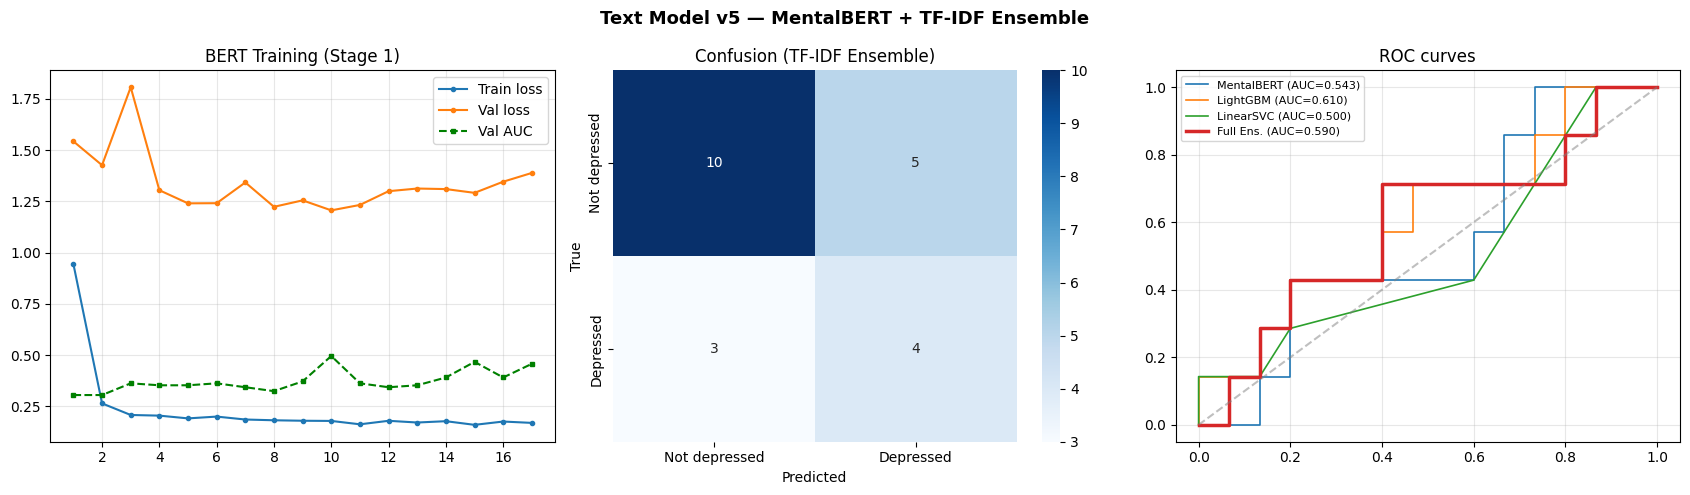

In [19]:
fig, axes = plt.subplots(1,3, figsize=(17,5))

# Training curve
ep = range(1,len(hist['tl'])+1)
axes[0].plot(ep,hist['tl'],label='Train loss',marker='o',ms=3)
axes[0].plot(ep,hist['vl'],label='Val loss',  marker='o',ms=3)
axes[0].plot(ep,hist['vauc'],label='Val AUC', marker='s',ms=3,ls='--',color='green')
axes[0].set_title('BERT Training (Stage 1)'); axes[0].legend(); axes[0].grid(alpha=.3)

# Confusion matrix — best model
cm = confusion_matrix(byt, bp)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=axes[1])
axes[1].set_title(f'Confusion ({best_name})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

# ROC curves
for name, prob, ytrue in [
    ('MentalBERT', bert_prob,    y_true),
    ('LightGBM',   lgbm_te_prob, yte),
    ('LinearSVC',  svc_te_prob,  yte),
    ('Full Ens.',  full_prob,    y_true)
]:
    fpr,tpr,_ = roc_curve(ytrue,prob)
    lw = 2.5 if 'Ens' in name else 1.2
    axes[2].plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(ytrue,prob):.3f})',lw=lw)
axes[2].plot([0,1],[0,1],'--',color='gray',alpha=.5)
axes[2].set_title('ROC curves'); axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)

plt.suptitle('Text Model v5 — MentalBERT + TF-IDF Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT,'text_results_v5.png'),dpi=150)
plt.show()

## Step 17 — Save all models + extract embeddings

In [20]:
# Save TF-IDF models
joblib.dump(lgbm,  os.path.join(OUT,'lgbm_text.pkl'))
joblib.dump(svc,   os.path.join(OUT,'svc_text.pkl'))
joblib.dump(lr,    os.path.join(OUT,'lr_text.pkl'))
joblib.dump(tfidf, os.path.join(OUT,'tfidf.pkl'))
print('TF-IDF models saved')

# Extract BERT embeddings for all clinical participants
all_ds  = TranscriptDataset(combined_df['text'], combined_df['label'])
all_ldr = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False)
model.eval(); embs=[]
with torch.no_grad():
    for b in tqdm(all_ldr, desc='BERT embed'):
        embs.append(model.get_embedding(b['input_ids'].to(DEVICE),
                                         b['attention_mask'].to(DEVICE)).cpu().numpy())
bert_emb = np.vstack(embs)
ids_arr  = combined_df['participant_id'].values

# TF-IDF ensemble probability embeddings
X_all    = build_X(combined_df)
ens_emb  = (W_LGBM*lgbm.predict_proba(X_all) +
            W_SVC *svc.predict_proba(X_all)  +
            W_LR  *lr.predict_proba(X_all))

np.savez(os.path.join(OUT,'text_embeddings.npz'),   embeddings=bert_emb, ids=ids_arr)
np.savez(os.path.join(OUT,'text_emb_ensemble.npz'), embeddings=ens_emb,  ids=ids_arr)

print(f'BERT embeddings   : {bert_emb.shape}  (→ fusion_model.text_dim={bert_emb.shape[1]})')
print(f'TF-IDF embeddings : {ens_emb.shape}')

TF-IDF models saved


BERT embed:   0%|          | 0/9 [00:00<?, ?it/s]

BERT embeddings   : (142, 1536)  (→ fusion_model.text_dim=1536)
TF-IDF embeddings : (142, 2)


## Summary

In [21]:
print('\n' + '='*65)
print('  FINAL SUMMARY')
print('='*65)
print(f'  Best model  : {best_name}')
print(f'  Accuracy    : {best_m["accuracy"]:.4f}')
print(f'  F1-macro    : {best_m["f1_macro"]:.4f}')
print(f'  F1-positive : {best_m["f1_pos"]:.4f}')
print(f'  ROC-AUC     : {best_m["roc_auc"]:.4f}')
print(f'\n  5-Fold CV (LightGBM):')
print(f'  Accuracy={cv_acc:.4f}  F1-macro={cv_mf1:.4f}  AUC={cv_auc:.4f}')
print('='*65)
print('\nOutput files:')
for fn in sorted(os.listdir(OUT)):
    print(f'  {fn:<45} {os.path.getsize(os.path.join(OUT,fn))/1e6:.1f} MB')


  FINAL SUMMARY
  Best model  : TF-IDF Ensemble
  Accuracy    : 0.6364
  F1-macro    : 0.6071
  F1-positive : 0.5000
  ROC-AUC     : 0.5619

  5-Fold CV (LightGBM):
  Accuracy=0.7817  F1-macro=0.7361  AUC=0.7454

Output files:
  lgbm_text.pkl                                 0.4 MB
  lr_text.pkl                                   0.1 MB
  mentalbert_model.pt                           502.1 MB
  svc_text.pkl                                  0.2 MB
  text_emb_ensemble.npz                         0.0 MB
  text_embeddings.npz                           0.9 MB
  text_metrics.json                             0.0 MB
  text_results_v5.png                           0.1 MB
  tfidf.pkl                                     0.4 MB
  threshold_bert.png                            0.0 MB
  val_labels.npy                                0.0 MB
  val_probs.npy                                 0.0 MB
